In [20]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
%matplotlib inline

## Άσκηση - Σειρές Fouier στην πράξη

Οι Σειρές Fourier εισάγονται συνήθως ως μια πρώτη γνωριμία μας με το χώρο της συχνότητας. Ας δούμε πώς θα μπορούσαμε να επιβεβαιώσουμε θεωρητικές απαντήσεις μας σε Σειρές Fourier στην `Python`, και με χρήση αυτού του κώδικα, να μπορούμε να αναπαριστούμε γραφικά τη σειρά Fourier οποιουδήποτε περιοδικού σήματος.

Έστω λοιπόν η σειρά Fourier

$$ x(t) = \frac{A}{2} + \sum_{k=1}^{+\infty} \frac{A}{k\pi} \cos\left(2\pi k f_0 t + \frac{\pi}{2}\right)$$

για κάποια τιμή του $A$ και κάποιο $f_0$.

Ο κώδικας `Python` που την υλοποιεί είναι ο παρακάτω. Διαβάστε τον προσεκτικά παρέα με τα σχόλια.

In [21]:
# Ας ορίσουμε μια τιμή για το Α
A = 1

# Επιλέγουμε μια διαμέριση του άξονα του χρόνου
dt = 0.001

# Ας επιλέξουμε την περίοδο, και άρα τη θεμελιώδη συχνότητα, του περιοδικού σήματος
T0 = 1
f0 = 1/T0

# Κατασκευάζουμε τον άξονα του χρόνου πάνω στον οποίο θα σχεδιάσουμε τη Σειρά Fourier
# Έστω ότι θέλουμε να δούμε 4 περιόδους του σήματός μας, στο [-2Τ0, 2Τ0)
t = np.arange(start=-2*T0, stop=2*T0, step=dt)

# Δεν μπορούμε να πάρουμε άπειρα συνημίτονα, όπως δηλώνει η εξίσωση της Σειράς Fourier. 
# Πόσα λοιπόν θα περιέχονται στην προσέγγισή μας? Έστω 60.
N = 60

# Κατασκευάζουμε τον άξονα των ακεραίων k, από 1 ως και Ν
k = np.arange(start=1, stop=N+1, step=1)

# Η τιμή X0
X0 = A/2

# Οι συντελεστές Fourier της τριγωνομετρικής σειράς Fourier που έχουμε
Ak = A/(k*np.pi)

# Υπολογισμός
# 1ος τρόπος: χρήση for loop
# --------------------------
x1 = np.zeros((len(t))) # αρχικοποίηση

# Κατασκευάζουμε το k-οστό ημίτονο κάθε φορά και το προσθέτουμε στα προηγούμενα που έχουμε κατασκευάσει
for l in range(0, len(k)):
    x1 = x1 + Ak[l] * np.cos(2 * np.pi * k[l] * f0 * t + np.pi/2)

x1 = x1 + X0 # προσθέτουμε και το συντελεστή X0 στο τέλος

# 2ος τρόπος - πιο έξυπνος αλλά και λίγο πιο δυσνόητος: χρήση πολλ/σμου πινάκων
# -----------------------------------------------------------------------------
# Προσέξτε πως αποφεύγουμε τη χρήση βρόχου επανάληψης ορίζοντας το k σαν πίνακα
# ώστε να κάνουμε απευθείας πολλαπλασιασμό πινάκων
x2 = X0 + Ak * np.cos(2 * np.pi * np.matrix(k).T * f0 * t + np.pi/2)
# Έπειτα το μετατρέπουμε σε ndarray και αφαιρούμε τις περιττές διαστάσεις
x2 = np.squeeze(np.asarray(x2))

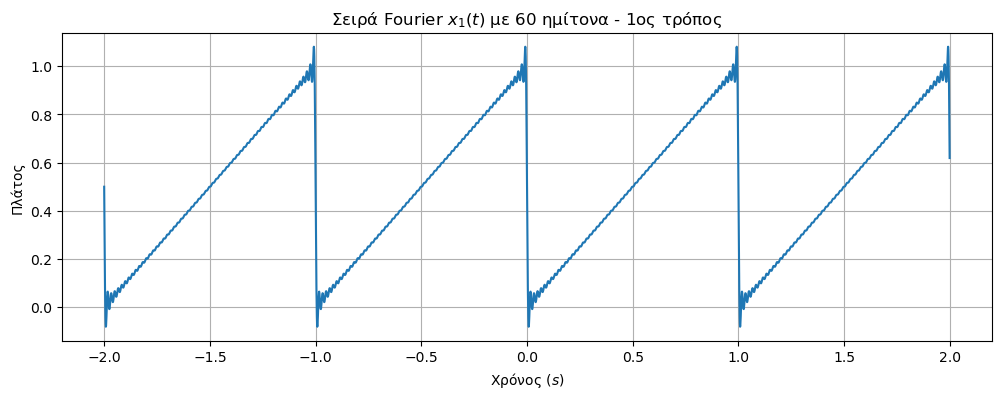

In [22]:
# Απεικόνιση
plt.figure(figsize=(12,4))                  # Ζητάμε να δημιουργηθεί ένα γράφημα με συγκεκριμένες διαστάσεις
plt.plot(t, x1)                             # Τυπώνουμε τη σειρά Fourier x1
plt.xlabel('Χρόνος $(s)$')                  # Ομορφαίνουμε
plt.ylabel('Πλάτος')                        # --||--
plt.title('Σειρά Fourier $x_1(t)$ με $60$ ημίτονα - 1ος τρόπος')  # --||--
plt.grid()
plt.show()                                  # Απεικόνιση

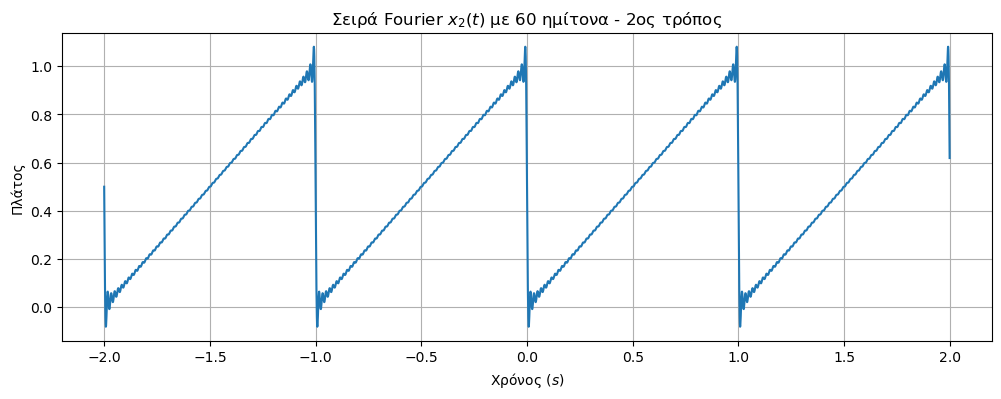

In [23]:
plt.figure(figsize=(12,4))                  # Ζητάμε να δημιουργηθεί ένα γράφημα με συγκεκριμένες διαστάσεις
plt.plot(t, x2)                             # Τυπώνουμε τη σειρά Fourier x2
plt.xlabel('Χρόνος $(s)$')                  # Ομορφαίνουμε
plt.ylabel('Πλάτος')                        # --||--
plt.title('Σειρά Fourier $x_2(t)$ με $60$ ημίτονα - 2ος τρόπος')  # --||--
plt.grid()
plt.show()                                  # Απεικόνιση

-----

Προγραμματίστε στην `Python` $4$ περιόδους από κάθε μία από τις παρακάτω σειρές Fourier. Χρησιμοποιήστε το χώρο που σας δίνεται παρακάτω.

I\. $ x_3(t) = \displaystyle \sum_{k=1}^{+\infty} \frac{4}{(k\pi)^2} \cos(2\pi k f_0 t) $

II\. $ x_4(t) = \displaystyle \frac{1}{5} + \sum_{k=1}^{+\infty} \frac{2\sin(k\pi/5)}{k\pi} \cos(2\pi k f_0 t) $

III\. $ x_5(t) = \displaystyle \sum_{k=1,\ k \ \text{περιττός}}^{+\infty} \frac{4}{k\pi} \sin(2\pi k f_0 t) $

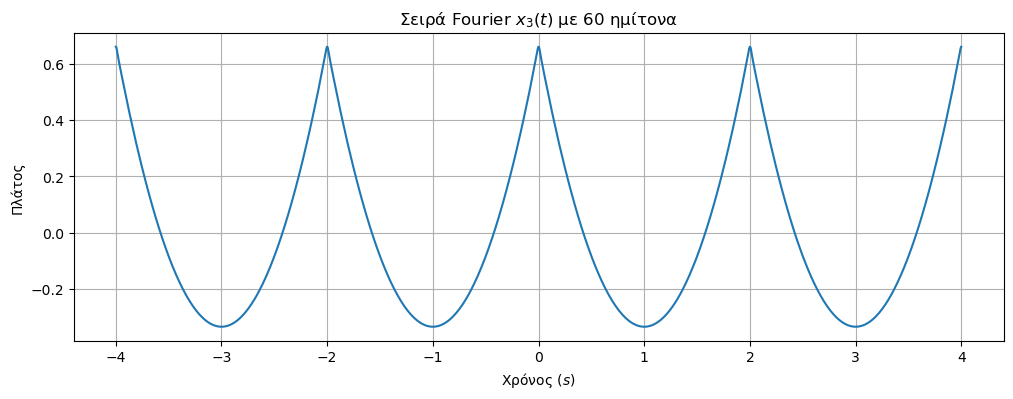

In [27]:
# I.

# Επιλέγουμε μια διαμέριση του άξονα του χρόνου
dt = 0.001

# Ας επιλέξουμε την περίοδο, και άρα τη θεμελιώδη συχνότητα, του περιοδικού σήματος
T0 = 2
f0 = 1/T0

# Κατασκευάζουμε τον άξονα του χρόνου πάνω στον οποίο θα σχεδιάσουμε τη Σειρά Fourier
# Έστω ότι θέλουμε να δούμε 4 περιόδους του σήματός μας, στο [-2Τ0, 2Τ0]
t = np.arange(start=-2*T0, stop=2*T0, step=dt)

# Πόσα ημίτονα θα περιέχονται στην προσέγγισή μας? Έστω 60.
N = 60

# Κατασκευάζουμε τον άξονα k
k = np.arange(start=1, stop=N+1, step=1)

# Η τιμή X0
X0 = 0

# Οι συντελεστές Fourier της τριγωνομετρικής σειράς Fourier που έχουμε
Ak = 4/(k*np.pi)**2

# Υπολογισμός
# 1ος τρόπος: χρήση for loop
# --------------------------
x3 = np.zeros((len(t))) # αρχικοποίηση

# Κατασκευάζουμε το k-οστό ημίτονο κάθε φορά και το προσθέτουμε στα προηγούμενα που έχουμε κατασκευάσει
for l in range(0, len(k)):
    x3 = x3 + Ak[l] * np.cos(2 * np.pi * k[l] * f0 * t)

x3 = x3 + X0 # προσθέτουμε και το συντελεστή X0 στο τέλος

# Απεικόνιση
plt.figure(figsize=(12,4))                  # Ζητάμε να δημιουργηθεί ένα γράφημα με συγκεκριμένες διαστάσεις
plt.plot(t, x3)                             # Τυπώνουμε τη σειρά Fourier x3
plt.xlabel('Χρόνος $(s)$')                  # Ομορφαίνουμε
plt.ylabel('Πλάτος')                        # --||--
plt.title('Σειρά Fourier $x_3(t)$ με $60$ ημίτονα')  # --||--
plt.grid()
plt.show()                                  # Απεικόνιση

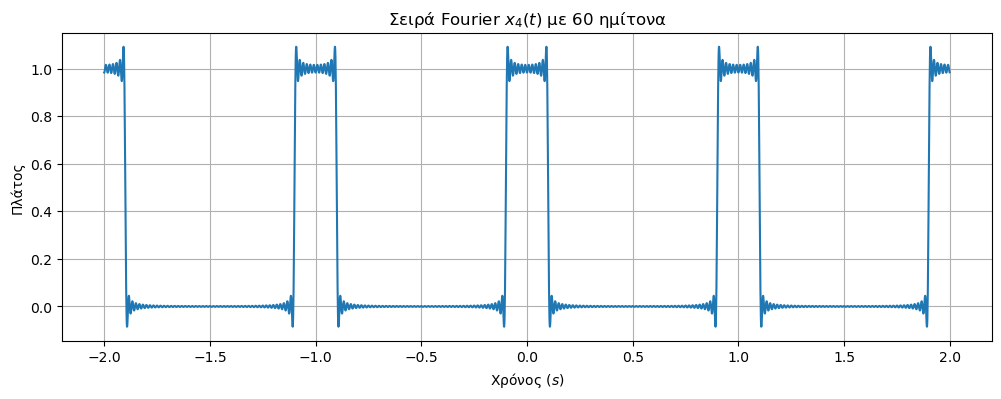

In [28]:
# II.

# Επιλέγουμε μια διαμέριση του άξονα του χρόνου
dt = 0.001

# Ας επιλέξουμε την περίοδο, και άρα τη θεμελιώδη συχνότητα, του περιοδικού σήματος
T0 = 1
f0 = 1/T0

# Κατασκευάζουμε τον άξονα του χρόνου πάνω στον οποίο θα σχεδιάσουμε τη Σειρά Fourier
# Έστω ότι θέλουμε να δούμε 4 περιόδους του σήματός μας, στο [-2Τ0, 2Τ0]
t = np.arange(start=-2*T0, stop=2*T0, step=dt)

# Πόσα ημίτονα θα περιέχονται στην προσέγγισή μας? Έστω 60.
N = 60

# Κατασκευάζουμε τον άξονα k
t = np.arange(start=-2*T0, stop=2*T0, step=dt)

# Κατασκευάζουμε τον άξονα k
k = np.arange(start=1, stop=N+1, step=1)

# Η τιμή X0
X0 = 1/5

# Οι συντελεστές Fourier της τριγωνομετρικής σειράς Fourier που έχουμε
Ak = 2*np.sin(k*np.pi/5)/(k*np.pi)

# Υπολογισμός
# 1ος τρόπος: χρήση for loop
# --------------------------
x4 = np.zeros((len(t))) # αρχικοποίηση

# Κατασκευάζουμε το k-οστό ημίτονο κάθε φορά και το προσθέτουμε στα προηγούμενα που έχουμε κατασκευάσει
for l in range(0, len(k)):
    x4 = x4 + Ak[l] * np.cos(2 * np.pi * k[l] * f0 * t)

x4 = x4 + X0 # προσθέτουμε και το συντελεστή X0 στο τέλος

# Απεικόνιση
plt.figure(figsize=(12,4))                  # Ζητάμε να δημιουργηθεί ένα γράφημα με συγκεκριμένες διαστάσεις
plt.plot(t, x4)                             # Τυπώνουμε τη σειρά Fourier x4
plt.xlabel('Χρόνος $(s)$')                  # Ομορφαίνουμε
plt.ylabel('Πλάτος')                        # --||--
plt.title('Σειρά Fourier $x_4(t)$ με $60$ ημίτονα')  # --||--
plt.grid()
plt.show()                                  # Απεικόνιση


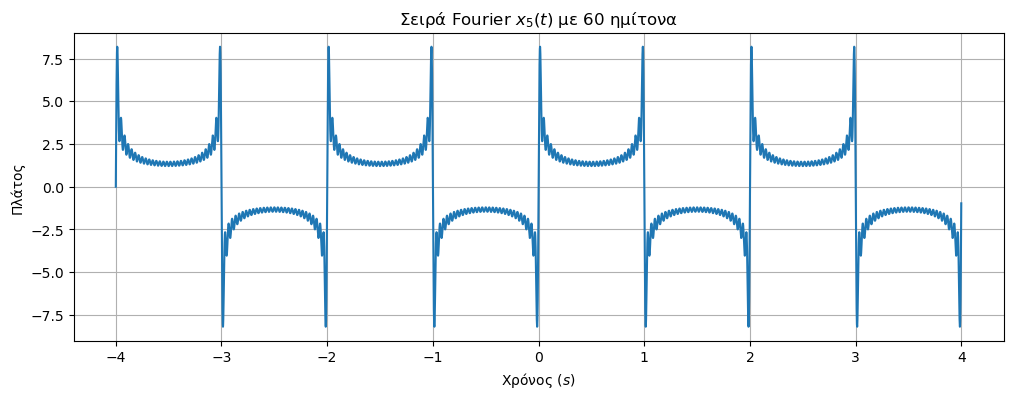

In [29]:
# III.

# Επιλέγουμε μια διαμέριση του άξονα του χρόνου
dt = 0.001

# Ας επιλέξουμε την περίοδο, και άρα τη θεμελιώδη συχνότητα, του περιοδικού σήματος
T0 = 2
f0 = 1/T0

# Κατασκευάζουμε τον άξονα του χρόνου πάνω στον οποίο θα σχεδιάσουμε τη Σειρά Fourier
# Έστω ότι θέλουμε να δούμε 4 περιόδους του σήματός μας, στο [-2Τ0, 2Τ0]
t = np.arange(start=-2*T0, stop=2*T0, step=dt)

# Πόσα ημίτονα θα περιέχονται στην προσέγγισή μας? Έστω 60.
N = 60

# Κατασκευάζουμε τον άξονα k
k = np.arange(start=1, stop=N+1, step=2)

# Η τιμή X0
X0 = 0

# Οι συντελεστές Fourier της τριγωνομετρικής σειράς Fourier που έχουμε
Ak = 2/np.sqrt(k)

# Υπολογισμός
# 1ος τρόπος: χρήση for loop
# --------------------------
x5 = np.zeros((len(t))) # αρχικοποίηση

# Κατασκευάζουμε το k-οστό ημίτονο κάθε φορά και το προσθέτουμε στα προηγούμενα που έχουμε κατασκευάσει
for l in range(0, len(k)):
    x5 = x5 + Ak[l] * np.sin(2 * np.pi * k[l] * f0 * t)

x5 = x5 + X0 # προσθέτουμε και το συντελεστή X0 στο τέλος

# Απεικόνιση
plt.figure(figsize=(12,4))                  # Ζητάμε να δημιουργηθεί ένα γράφημα με συγκεκριμένες διαστάσεις
plt.plot(t, x5)                             # Τυπώνουμε τη σειρά Fourier x5
plt.xlabel('Χρόνος $(s)$')                  # Ομορφαίνουμε
plt.ylabel('Πλάτος')                        # --||--
plt.title('Σειρά Fourier $x_5(t)$ με $60$ ημίτονα')  # --||--
plt.grid()
plt.show()                                  # Απεικόνιση


---
---